# Notebook 02: Lattice Navigation

**Learning objectives:**
- Map between lattice coordinates $(x,y,z,t)$ and linear indices
- Understand periodic boundary conditions
- Navigate forward and backward on the lattice
- Build precomputed neighbor tables for efficiency
- Visualize the even/odd checkerboard structure

**Prerequisites:** Notebook 01

**Key functions:** `su2.p2i()`, `i2p()`, `mupi()`, `mdowni()`, `getMups()`, `getMdns()`, `parity()`

In [2]:
from notebook_utils import setup_paths
setup_paths()

import numpy as np
import matplotlib.pyplot as plt
import su2

## 1. Lattice Dimensions and Volume

A 4D lattice with dimensions $L_x \times L_y \times L_z \times L_t$
has $V = L_x L_y L_z L_t$ sites. Each site is labeled by coordinates
$(x,y,z,t)$ **or** by a single linear index $i \in [0, V)$.

In [4]:
# TRY: Change La to [6, 6, 6, 20] (the lattice used for real data in Notebook 11)
#      or [2, 2, 2, 2] for the smallest non-trivial lattice
La = [4, 4, 4, 4]
V = su2.vol(La)
D = su2.dim(La)
print(f"Lattice: {La}")
print(f"Volume:  {V} sites")
print(f"Dims:    {D}")

Lattice: [4, 4, 4, 4]
Volume:  256 sites
Dims:    {0: 4, 1: 4, 2: 4, 3: 4}


## 2. Coordinate $\leftrightarrow$ Index Conversion

`p2i([x,y,z,t], La)` converts coordinates to a linear index.
`i2p(index, La)` converts back.

The ordering is row-major: $i = x + L_x y + L_x L_y z + L_x L_y L_z t$.

In [6]:
# Test round-trip for every site
for i in range(V):
    pt = su2.i2p(i, La)
    j = su2.p2i(pt, La)
    assert i == j, f"Round-trip failed at index {i}"

print(f"All {V} round-trip conversions passed!")

# Show a few examples
for pt in [[0,0,0,0], [1,0,0,0], [0,1,0,0], [3,3,3,3]]:
    idx = su2.p2i(pt, La)
    back = su2.i2p(idx, La)
    print(f"  {pt} -> index {idx:3d} -> {list(back)}")

All 256 round-trip conversions passed!
  [0, 0, 0, 0] -> index   0 -> [0, 0, 0, 0]
  [1, 0, 0, 0] -> index   1 -> [1, 0, 0, 0]
  [0, 1, 0, 0] -> index   4 -> [0, 1, 0, 0]
  [3, 3, 3, 3] -> index 255 -> [3, 3, 3, 3]


## 3. Periodic Boundary Conditions

The lattice wraps around: moving past the edge brings you back to the
opposite side. This eliminates surface effects and preserves
translational symmetry.

$x + \hat{\mu}$ at the boundary: coordinate $L_\mu - 1$ wraps to $0$.

In [8]:
# Forward neighbor: mupi(index, direction, La)
# Directions: 0=x, 1=y, 2=z, 3=t

corner = su2.p2i([3, 3, 3, 3], La)  # far corner
fwd_x = su2.mupi(corner, 0, La)
print(f"Site [3,3,3,3] (index {corner})")
print(f"  +x neighbor: index {fwd_x} = {list(su2.i2p(fwd_x, La))}")
# Should wrap to [0,3,3,3]

# Backward neighbor: mdowni(index, direction, La)
origin = su2.p2i([0, 0, 0, 0], La)
bwd_t = su2.mdowni(origin, 3, La)
print(f"\nSite [0,0,0,0] (index {origin})")
print(f"  -t neighbor: index {bwd_t} = {list(su2.i2p(bwd_t, La))}")
# Should wrap to [0,0,0,3]

Site [3,3,3,3] (index 255)
  +x neighbor: index 252 = [0, 3, 3, 3]

Site [0,0,0,0] (index 0)
  -t neighbor: index 192 = [0, 0, 0, 3]


## 4. Precomputed Neighbor Tables

Computing neighbors on-the-fly for every lattice sweep is slow.
Instead we build tables `mups[i, mu]` and `mdns[i, mu]` once.

In [10]:
mups = su2.getMups(V, len(La), La)
mdns = su2.getMdns(V, len(La), La)

print(f"mups shape: {mups.shape}  (V x ndim)")
print(f"mdns shape: {mdns.shape}")

# Verify: forward then backward should return to start
for i in range(V):
    for mu in range(4):
        fwd = mups[i, mu]
        back = mdns[fwd, mu]
        assert back == i, f"Failed at site {i}, dir {mu}"

print("All forward-backward consistency checks passed!")

mups shape: (256, 4)  (V x ndim)
mdns shape: (256, 4)
All forward-backward consistency checks passed!


## 5. Checkerboard Parity

The lattice splits into **even** and **odd** sublattices based on
$p = (x + y + z + t) \bmod 2$.
This is used for even-odd preconditioning of the Dirac operator.

In [12]:
# Count even and odd sites
n_even = sum(1 for i in range(V) if su2.parity(su2.i2p(i, La)) == 0)
n_odd = V - n_even
print(f"Even sites: {n_even}, Odd sites: {n_odd}")
assert n_even == n_odd == V // 2

Even sites: 128, Odd sites: 128


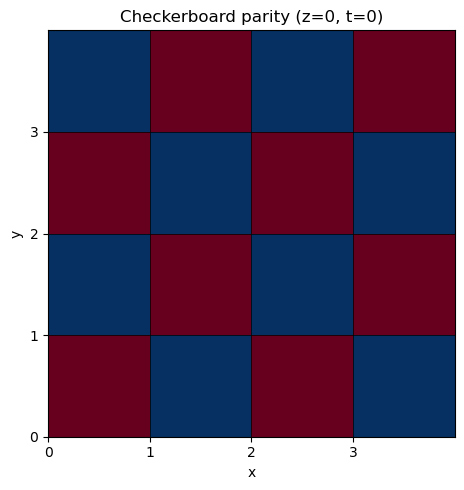

In [13]:
# Visualize a 2D slice (x-y plane at z=0, t=0)
Lx, Ly = La[0], La[1]
grid = np.zeros((Ly, Lx))

for x in range(Lx):
    for y in range(Ly):
        grid[y, x] = su2.parity(np.array([x, y, 0, 0]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(grid, cmap='RdBu', origin='lower', extent=[0, Lx, 0, Ly])
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Checkerboard parity (z=0, t=0)')
ax.set_xticks(range(Lx)); ax.set_yticks(range(Ly))
ax.grid(True, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

Every even site's nearest neighbors are all odd, and vice versa.
This bipartite structure allows the Dirac operator to be block-decomposed:
$$D = \begin{pmatrix} M_{ee} & D_{eo} \\ D_{oe} & M_{oo} \end{pmatrix}$$

## Exercises

1. For a $6^3 \times 20$ lattice, how many sites are there? How large is the
   Dirac matrix ($8V \times 8V$, where $8 = 2$ colors $\times$ $4$ spins)?
2. Starting from the origin, take 4 steps in the $+x$ direction on a $4^4$
   lattice. Where do you end up? Verify with `mupi`.
3. Verify that a nearest neighbor of an even site is always odd.
4. **Lattice distance**: Write a function to compute the shortest distance
   (in lattice units, with periodic BC) between two sites.
   For sites at $(0,0,0,0)$ and $(3,3,3,3)$ on a $4^4$ lattice,
   is the distance $\sqrt{4 \times 3^2}$ or $\sqrt{4 \times 1^2}$?
   (Remember: on a periodic $L=4$ lattice, distance 3 is the same as distance 1.)
5. **Asymmetric lattices**: Change `La` to `[4, 4, 4, 8]` and rebuild the
   neighbor tables. How does the volume change? Real lattice simulations
   use $L_t > L_s$ because the temporal extent determines the temperature
   $T = 1/(a L_t)$, and longer time extents give better mass extraction
   from correlator plateaus.
6. **Memory scaling**: For lattice sizes $L = 4, 8, 16, 32$, compute the
   memory (in MB) needed to store the SU(2) gauge field $U(V, 4, 4)$
   as float64. At what $L$ does this exceed 1 GB?
   (*Formula:* $V \times 4 \times 4 \times 8$ bytes.)